In [36]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [17]:
import os
from PIL import Image

source = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages"
cleaned = "/kaggle/working/PetImages_clean"

os.makedirs(cleaned, exist_ok=True)

bad_files = []
converted = 0

for class_name in os.listdir(source):

    source_class = os.path.join(source, class_name)
    cleaned_class = os.path.join(cleaned, class_name)

    if not os.path.isdir(source_class):
        continue

    os.makedirs(cleaned_class, exist_ok=True)

    for filename in os.listdir(source_class):

        source_path = os.path.join(source_class, filename)
        cleaned_path = os.path.join(cleaned_class, filename)

        try:
            img = Image.open(source_path)

            # Convert every image to RGB
            if img.mode != "RGB":
                converted += 1

            img = img.convert("RGB")
            img.save(cleaned_path)

        except Exception as e:
            bad_files.append((source_path, str(e)))

print("Images converted:", converted)
print("Bad images:", len(bad_files))

for file in bad_files[:20]:
    print(file)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Images converted: 67
Bad images: 0


In [18]:
dataset_path = "/kaggle/working/PetImages_clean"

In [27]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Conv2D , MaxPooling2D , Flatten , BatchNormalization , Dropout

In [20]:
#generators
data = keras.utils.image_dataset_from_directory(
    directory = dataset_path,
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256 , 256),
)

Found 24998 files belonging to 2 classes.


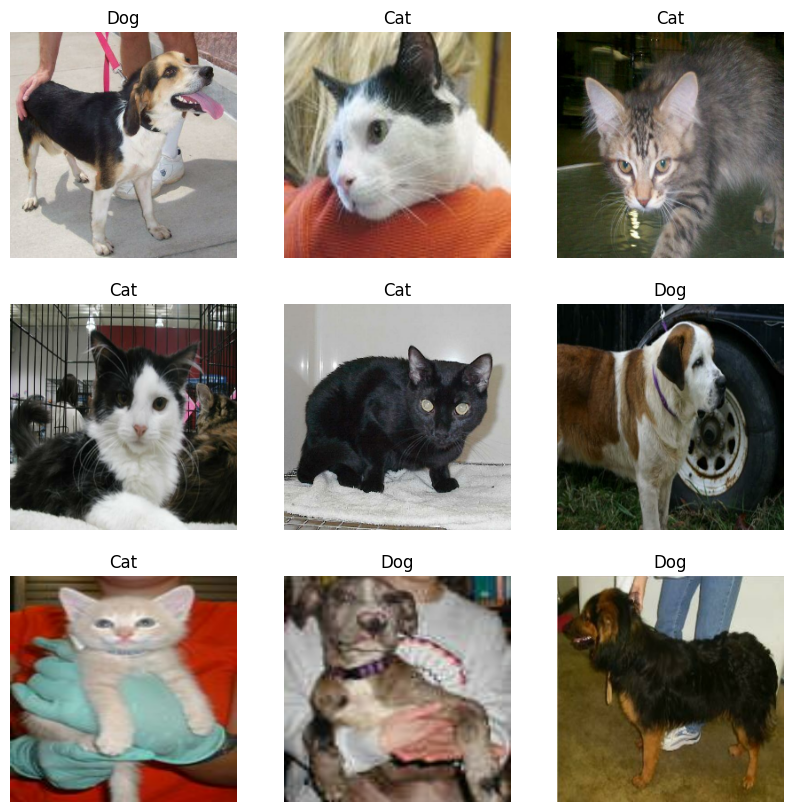

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(data.class_names[labels[i]])
        plt.axis("off")

In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(256, 256),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(256, 256),
    batch_size=32
)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [23]:
#Normalize

def process(image , label):
    image = tf.cast(image/255. , tf.float32)
    return image , label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [ ]:
#CNN model

model = Sequential()
model.add(Conv2D(32 , kernel_size=(3 , 3) , padding = 'valid' , activation = 'relu' , input_shape = (256 ,256 , 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2 , 2) , strides = 2 , padding = 'valid'))

model.add(Conv2D(64 , kernel_size=(3 , 3) , padding = 'valid' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2 , 2) , strides = 2 , padding = 'valid'))

model.add(Conv2D(128 , kernel_size=(3 , 3) , padding = 'valid' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2 , 2) , strides = 2 , padding = 'valid'))

model.add(Flatten())

model.add(Dense(128 , activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64 , activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(1 , activation='sigmoid'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

In [30]:
model.compile(optimizer = 'adam' , loss='binary_crossentropy' , metrics=['accuracy'])


In [32]:
history = model.fit(train_ds , epochs=15 , validation_data = val_ds)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.6297 - loss: 0.9339 - val_accuracy: 0.6819 - val_loss: 0.5900
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7293 - loss: 0.5508 - val_accuracy: 0.7369 - val_loss: 0.5373
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7854 - loss: 0.4621 - val_accuracy: 0.7880 - val_loss: 0.4681
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 86ms/step - accuracy: 0.8130 - loss: 0.4147 - val_accuracy: 0.7986 - val_loss: 0.4471
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8516 - loss: 0.3439 - val_accuracy: 0.7860 - val_loss: 0.4800
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.8962 - loss: 0.2533 - val_accuracy: 0.7614 - val_loss: 0.6834
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9247 - loss: 0.1925 - val_accuracy: 0.8032 - val_loss: 0.6485
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9542 - loss: 0.1232 - 

In [33]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Training Loss:", history.history["loss"][-1])

print("Final Validation Accuracy:", history.history["val_accuracy"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.9866493344306946
Final Training Loss: 0.04319543018937111
Final Validation Accuracy: 0.7567513585090637
Final Validation Loss: 3.082334041595459


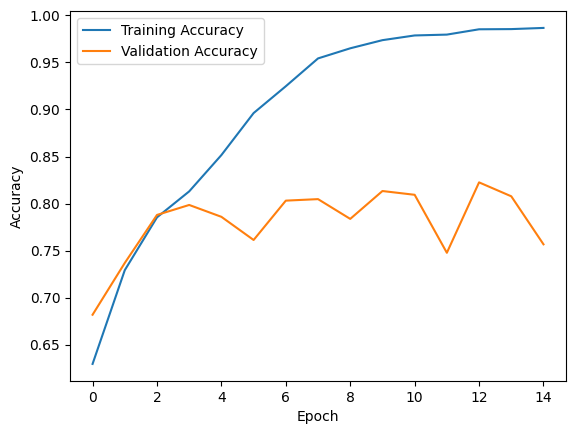

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

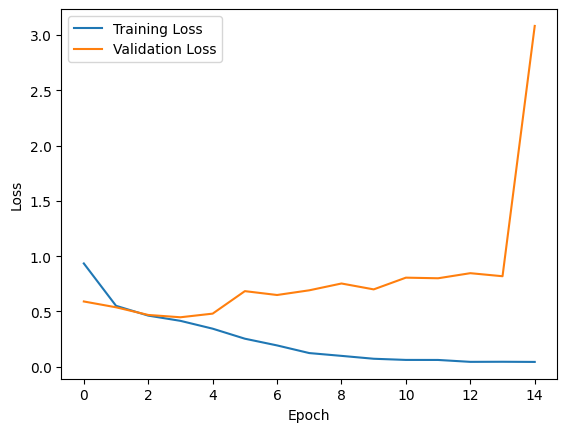

In [35]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()